## Introduction
### Overarching Question : How do different recipe characteristics influence user ratings?
Recipe data offers valuable insights into consumer preferences, revealing how factors such as cuisine, nutritional content, and preparation time shape how people choose what to cook and eat.

In this report we will be using two dataset: all_recpies.csv and cuisines.csv which contains information on various recipes, including their cuisine type, calorie content, preparation time, and user ratings. 

Our three criterias of focus are: 
Calories 
Cuisine type 
Total preparation time 
so as to investigate their relationship with recipe ratings.

### Overview of the dataset:
Food and recipe datasets provide valuable insights into culinary preferences and consumption patterns across different populations. The dataset used in this project comes from the TidyTuesday initiative, which provides real-world datasets for data exploration and visualization. This particular dataset contains information on a wide range of recipes, including attributes such as cuisine type, calorie content, total preparation time, and user ratings. Each observation represents a single recipe, allowing for comparisons across different types of dishes and cooking styles. By organizing recipe characteristics alongside user feedback, the dataset enables analysis of how factors like nutritional value, cooking time, and cuisine influence the popularity and perceived quality of recipes


## Data Cleaning and Preparation
To ensure the quality of the analysis, several data cleaning steps were performed. Firstly, we focused only on the cuisine-based dataset, as the full recipe dataset lacked consistent country information.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
all_recipes = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/all_recipes.csv')
#make sure the plots are 3 distinct visualisation; plot is easliy interpretable; if showcase derived variables not in original, include in the plot as a subtitle 
#discourage the use of pie chart and dual axis plots 
#external datasets are not allowed 
#CSS is okay but need to include in notebook itself 
all_recipes.head()

cuisines = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/cuisines.csv')
print(cuisines.info())
print(cuisines.describe())


<class 'pandas.DataFrame'>
RangeIndex: 2218 entries, 0 to 2217
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2218 non-null   str    
 1   country         2218 non-null   str    
 2   url             2218 non-null   str    
 3   author          2218 non-null   str    
 4   date_published  2218 non-null   str    
 5   ingredients     2217 non-null   str    
 6   calories        2186 non-null   float64
 7   fat             2163 non-null   float64
 8   carbs           2183 non-null   float64
 9   protein         2179 non-null   float64
 10  avg_rating      2121 non-null   float64
 11  total_ratings   2121 non-null   float64
 12  reviews         2110 non-null   float64
 13  prep_time       2218 non-null   int64  
 14  cook_time       2218 non-null   int64  
 15  total_time      2218 non-null   int64  
 16  servings        2216 non-null   float64
dtypes: float64(8), int64(3), str(6)
memory usage

We chose to remove missing values instead of imputing since we have sufficient data to capture trends, though we did experiment on the latter method.

In [39]:
HADNLE_MISSING = "drop" # options: "drop", "impute"
print(len(cuisines))
# use drop if we have enough data
if HADNLE_MISSING == "drop": # drops 126 rows, leaving us with 2092 rows, probably enough EDIT: yes enough
  cuisines_handle_missing = cuisines.dropna(subset=['country', 'calories', 'total_time', 'avg_rating'])
# impute might introduce bias, but it allows us to keep more data
elif HADNLE_MISSING == "impute":
  # impute missing values with median for calories, total_time, and rating and unknown for country
  cuisines_handle_missing = cuisines.copy()
  cuisines_handle_missing['calories'] = cuisines_handle_missing['calories'].fillna(cuisines_handle_missing['calories'].median())
  cuisines_handle_missing['total_time'] = cuisines_handle_missing['total_time'].fillna(cuisines_handle_missing['total_time'].median())
  cuisines_handle_missing['country'] = cuisines_handle_missing['country'].fillna('unknown')
  cuisines_handle_missing['avg_rating'] = cuisines_handle_missing['avg_rating'].fillna(cuisines_handle_missing['avg_rating'].median())



2218


We set the country to be a categorical variable. Additionally, rows with a total preparation time of zero were removed, since these values indicated missing data rather than actual cooking time (verified by checking the links)

In [31]:
cuisines_handle_missing['country'] = cuisines_handle_missing['country'].astype('category')
cuisines_handle_missing = cuisines_handle_missing[cuisines_handle_missing['total_time'] > 0]
print(len(cuisines_handle_missing))

2043


For countries with low counts, we chose to group them to “Others”

In [40]:
# check country counts
# print(cuisines_handle_missing['country'].value_counts())

GROUP_OTHERS = True
if GROUP_OTHERS:
  country_counts = cuisines_handle_missing['country'].value_counts()
  countries_to_group = country_counts[country_counts < 15].index
  cuisines_handle_missing['country'] = cuisines_handle_missing['country'].apply(lambda x: 'Other' if x in countries_to_group else x)

  We also chose to remove outliers for calories and total_time. This is because our goal is to capture the general trend, which might be skewed by outliers. 

In [41]:
Q1 = cuisines_handle_missing[['calories', 'total_time']].quantile(0.25)
Q3 = cuisines_handle_missing[['calories', 'total_time']].quantile(0.75)
IQR = Q3 - Q1
l_out_cutoff = Q1 - 1.5 * IQR
h_out_cutoff = Q3 + 1.5 * IQR
print(l_out_cutoff)
print(h_out_cutoff)


cuisines_no_out = cuisines_handle_missing[~((cuisines_handle_missing[['calories', 'total_time']] < (l_out_cutoff)) | 
              (cuisines_handle_missing[['calories', 'total_time']] > (h_out_cutoff))).any(axis=1)]

REMOVE_OUTLIERS = True
if REMOVE_OUTLIERS:
  cuisines_cleaned = cuisines_no_out.copy()
else:
  cuisines_cleaned = cuisines_handle_missing.copy()
print(len(cuisines_cleaned)) # left with 1765 data if drop is used, 1871 if impute is used

calories     -240.875
total_time    -92.500
dtype: float64
calories      908.125
total_time    247.500
dtype: float64
1805


Lastly, we also binned the calories and total_time into 5 categories, which we will use for our heatmap plot. For reference, the ranges of our bins are shown below:

| Calorie Bin | Range | Time Bin | Range |
|---|---|---|---|
| Very low | (2.097, 183.6] | Very short | (0.741, 52.8] |
| Low | (183.6, 364.2] | Short | (52.8, 104.6] |
| Normal | (364.2, 544.8] | Moderate | (104.6, 156.4] |
| High | (544.8, 725.4] | Long | (156.4, 208.2] |
| Very high | (725.4, 906.0] | Very long | (208.2, 260.0] |

In [42]:
# group by each criterion and calculate the average rating for each group
cuisines_by_country = cuisines_cleaned.groupby('country')['avg_rating']\
  .mean()\
  .reset_index()\
  .sort_values(by='avg_rating', ascending=False)
cuisines_by_calories = cuisines_cleaned[['calories', 'avg_rating']]\
  .copy()\
  .sort_values('calories')\
  .reset_index(drop = True)
cuisines_by_total_time = cuisines_cleaned[['total_time', 'avg_rating']]\
  .copy()\
  .sort_values('total_time')\
  .reset_index(drop = True)
cuisines_by_calories_binned = cuisines_cleaned.copy()
cuisines_by_calories_binned['calories_bin'] = pd.cut(cuisines_by_calories_binned['calories'], bins=5)
cuisines_by_calories_binned = cuisines_by_calories_binned.groupby('calories_bin')['avg_rating']\
  .mean()\
  .reset_index()\
  .sort_values(by='avg_rating', ascending=False)

cuisines_by_total_time_binned = cuisines_cleaned.copy()
cuisines_by_total_time_binned['total_time_bin'] = pd.cut(cuisines_by_total_time_binned['total_time'], bins=5)
cuisines_by_total_time_binned = cuisines_by_total_time_binned.groupby('total_time_bin')['avg_rating']\
  .mean()\
  .reset_index()\
  .sort_values(by='avg_rating', ascending=False)

print(len(cuisines_by_country))
print(len(cuisines_by_calories))
print(len(cuisines_by_total_time))

46
1805
1805


A quick calculation for the correlation between average rating with calories and total_time shows very low correlations between them. However, this does not tell the full story as the relationship could be non-linear, joint, or captured within the country variable instead. Our plots will try to capture the trends that correlation could not.


In [35]:
cor_cal = cuisines_cleaned['avg_rating'].corr(cuisines_cleaned['calories'])
cor_time = cuisines_cleaned['avg_rating'].corr(cuisines_cleaned['total_time'])

print(cor_cal, cor_time)

0.027679142856490875 -0.006092581047788586


## Plot 1: Choropleth map of average ratings by cuisine type
### Guiding question: Does the cuisine type of a recipe affect its average rating?
To explore how recipe ratings vary across different cuisines globally, we used a choropleth map (heatmap). This is effective for displaying geographical patterns, allowing us to easily compare average ratings across countries and identify regional trends.
Since the dataset uses cuisine names rather than actual country names, we created a mapping dictionary to match each cuisine to its corresponding country. This step is necessary for plotting on a world map, as the visualization requires standardized country names.
Finally, we used Plotly Express to generate the choropleth map. The location parameter specifies the country names, while color represents the average rating. A red-to-green color scale (RdYlGn) was used, where lower ratings are shown in red and higher ratings in green. Since most ratings fall between 4 and 5, we constrained the color range to (4, 5) to enhance visual contrast.




In [36]:
#First Plot: heatmap plot of countries with the average rating of cuisines 
import plotly.express as px

# Average rating by "country"
country_rating = (
    cuisines_cleaned
    .groupby('country', as_index=False)['avg_rating']
    .mean()
)

# Map cuisine labels to actual country names
country_iso3_map = {
    'Canadian': 'CAN',
    'Chinese': 'CHN',
    'Cuban': 'CUB',
    'Indian': 'IND',
    'Russian': 'RUS',
    'Filipino': 'PHL',
    'French': 'FRA',
    'Brazilian': 'BRA',
    'Vietnamese': 'VNM',
    'Polish': 'POL',
    'Puerto Rican': 'PRI',
    'Thai': 'THA',
    'Japanese': 'JPN',
    'Greek': 'GRC',
    'Italian': 'ITA',
    'Korean': 'KOR',
    'German': 'DEU',
    'Spanish': 'ESP',
    'Portuguese': 'PRT',
    'Lebanese': 'LBN',
    'Jamaican': 'JAM',
    'Persian': 'IRN',
    'Peruvian': 'PER',
    'Danish': 'DNK',
    'Argentinian': 'ARG',
    'Swedish': 'SWE',
    'Turkish': 'TUR',
    'Israeli': 'ISR',
    'Norwegian': 'NOR',
    'Indonesian': 'IDN',
    'Malaysian': 'MYS',
    'Pakistani': 'PAK',
    'South African': 'ZAF',
    'Austrian': 'AUT',
    'Dutch': 'NLD',
    'Chilean': 'CHL',
    'Finnish': 'FIN',
    'Bangladeshi': 'BGD',
    'Colombian': 'COL',
    'Swiss': 'CHE',
    'Belgian': 'BEL'
}

# apply mapping
country_rating['iso3'] = country_rating['country'].map(country_iso3_map)

# keep only rows that were successfully mapped
country_rating_map = country_rating.dropna(subset=['iso3']).copy()

# Plot choropleth
# low = red, high = green
# Since all the ratings are at least above 4, I put the scale to be [4,5]
fig = px.choropleth(
    country_rating_map,
    locations='iso3',
    locationmode='ISO-3',
    color='avg_rating',
    hover_name='country',
    hover_data={
        'avg_rating': ':.2f'
    },
    color_continuous_scale='RdYlGn',
    range_color=(4, 5),
    title='Average Recipe Ratings by Country/Cuisine Origin'
)

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    ),
    coloraxis_colorbar=dict(title='Avg Rating'),
    title_x=0.5
)

fig.show()

# NOTE: we cannot get plotly to show on html, so we just screenshot and paste

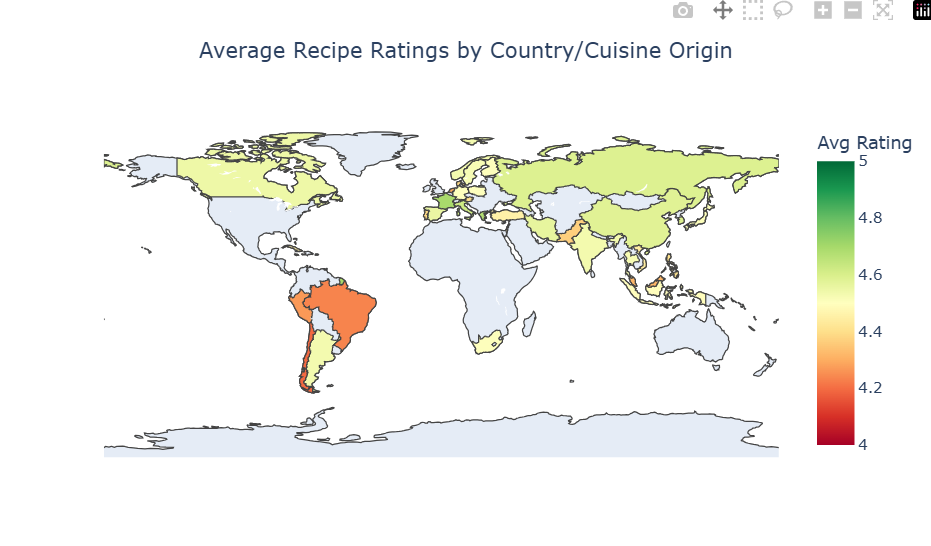

The choropleth map illustrates how average recipe ratings vary across different cuisines globally, highlighting subtle regional differences. While most cuisines fall within a relatively high rating range (around 4.2 to 4.7), the visualization shows that European cuisines, particularly Western European countries like France and Greece, tend to have slightly higher ratings, as indicated by the greener shades. In contrast, some cuisines from regions such as parts of South America (e.g. Brazil, Chile) appear in more orange tones, reflecting comparatively lower average ratings.
This pattern may be influenced by factors such as global popularity and familiarity. Cuisines that are more widely known and commonly cooked may receive higher ratings due to greater user familiarity and refined recipes. On the other hand, cuisines that are less frequently tried or have fewer representations in the dataset may show slightly lower ratings. Overall, the visualization highlights that although ratings are generally high across all cuisines, there are still noticeable regional variations that reflect differences in exposure, preference, and representation in the data.

## Plot 2: Bubble Plot – Cuisine Profiles: Time, Calories, and Ratings

### Guiding question: How does the cooking time and calories affect the average rating of a recipe across different cuisines?

For the first visualisation, we used **Matplotlib’s scatter plot** to construct a bubble chart, as it is suitable for comparing multiple recipe characteristics simultaneously. Each bubble represents one cuisine, while text labels directly on the bubble so that cuisines can be identified directly without referring to a legend. The x-axis shows the average total time in minutes, while the y-axis shows the average calories per recipe, allowing us to compare how “effort” and “richness” vary across cuisines. Colour represents average rating, with greener bubbles indicating higher-rated cuisines and warmer orange-red tones indicating relatively lower-rated cuisines. Bubble size represents the number of recipes in each cuisine group, so larger bubbles reflect cuisines with more observations in the dataset.

To improve the reliability of the comparison, we decided to select only the top 20 cuisines with the largest recipe counts. This ensures that cuisines with very small sample sizes do not disproportionately affect the visual patterns, while also improving readability by limiting clutter in the final chart.  In addition to this, we also chose the average rating scale to be (4, 5) to highlight the variations and relative comparison among the cooking time, ratings and calories, since the majority of the cuisines are rated highly, thus a (0, 5) scale could obscure important trends. 


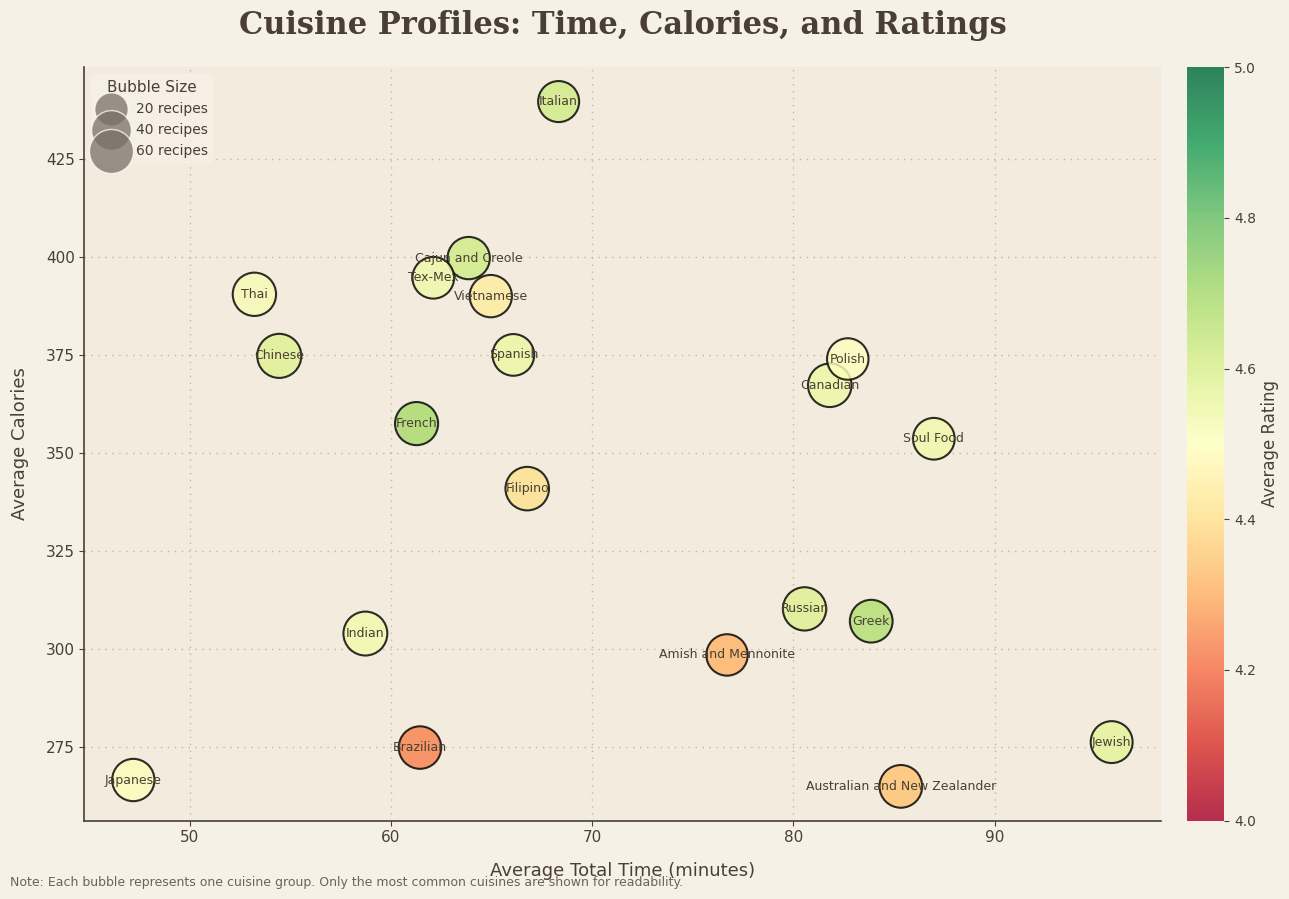

In [37]:
# Plot 2: Bubble plot of countries an their average rating against mean calories on x axis and mean total_time on y-axis
#this only includes the top 20 countries sorted by sample size 
country_bubble = (
    cuisines_cleaned
    .groupby('country', as_index=False)
    .agg(
        mean_rating=('avg_rating', 'mean'),
        mean_calories=('calories', 'mean'),
        mean_total_time=('total_time', 'mean'),
        n_recipes=('avg_rating', 'size')
    )
)

top_n = 20
country_bubble = country_bubble.sort_values('n_recipes', ascending=False).head(top_n).copy()

bg_color = '#F6F1E7'
panel_color = '#F3EBDD'
text_color = '#4A3F35'
grid_color = '#B8AA96'

bubble_sizes = np.sqrt(country_bubble['n_recipes']) * 130

fig, ax = plt.subplots(figsize=(14, 9), facecolor=bg_color)
ax.set_facecolor(panel_color)

scatter = ax.scatter(
    country_bubble['mean_total_time'],
    country_bubble['mean_calories'],
    s=bubble_sizes,
    c=country_bubble['mean_rating'],
    cmap='RdYlGn',
    vmin=4,
    vmax=5,
    alpha=0.82,
    edgecolors='black',
    linewidths=1.5,
    zorder=2
)

for _, row in country_bubble.iterrows():
    ax.text(
        row['mean_total_time'],
        row['mean_calories'],
        row['country'],
        fontsize=9,
        color=text_color,
        ha='center',
        va='center',
        zorder=4
    )

ax.set_title(
    'Cuisine Profiles: Time, Calories, and Ratings',
    fontsize=22,
    weight='bold',
    color=text_color,
    pad=24,
    family='serif'
)

ax.set_xlabel('Average Total Time (minutes)', fontsize=13, color=text_color, labelpad=12)
ax.set_ylabel('Average Calories', fontsize=13, color=text_color, labelpad=12)

ax.tick_params(axis='x', colors=text_color, labelsize=11)
ax.tick_params(axis='y', colors=text_color, labelsize=11)

# dotted grid like your example
ax.grid(True, linestyle=(0, (1, 4)), linewidth=1, color=grid_color, alpha=0.8)
ax.set_axisbelow(True)

# spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(text_color)
    ax.spines[spine].set_linewidth(1.2)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Average Rating', fontsize=12, color=text_color)
cbar.ax.tick_params(labelsize=10, colors=text_color)
cbar.outline.set_visible(False)

# choose example recipe counts
size_examples = [20, 40, 60]
handles = [
    plt.scatter([], [], s=np.sqrt(s) * 130, color='#7A7066', alpha=0.75, edgecolors='white')
    for s in size_examples
]
labels = [f'{s} recipes' for s in size_examples]

legend = ax.legend(
    handles, labels,
    title='Bubble Size',
    loc='upper left',
    frameon=True,
    facecolor=bg_color,
    edgecolor='none',
    fontsize=10,
    title_fontsize=11
)

plt.setp(legend.get_texts(), color=text_color)
plt.setp(legend.get_title(), color=text_color)

fig.text(
    0.01, 0.01,
    'Note: Each bubble represents one cuisine group. Only the most common cuisines are shown for readability.',
    fontsize=9,
    color='#6E6255'
)

plt.tight_layout()
plt.show()

From the bubble plot, we can observe that highly rated cuisines are spread across a wide range of cooking times and calorie levels, suggesting that there is no single “ideal” recipe profile that guarantees strong ratings. For example, Italian cuisine stands out as one of the highest-calorie groups and is also highly rated, while Greek cuisine achieves similarly strong ratings despite having much lower average calories. This suggests that rating is not driven by calories alone. Likewise, highly rated cuisines appear at both moderate and longer cooking times, indicating that recipes do not need to be especially fast or especially time-intensive to perform well.

We also noticed that cuisines with mid to low ratings (4.5-4) tend to cluster more clearly in certain regions. Brazilian, Amish and Mennonite, and Australian and New Zealander cuisines appear in more orange tones, indicating lower average ratings relative to the rest of the sample. These cuisines are not extreme in both calories and cooking time at once, which suggests that lower ratings are also unlikely to be explained by a single numeric factor alone. Instead, cuisine identity may matter alongside recipe characteristics.

Some outliers from this graph include Italian cuisine which combines relatively high calories with relatively moderate cooking time, yet still receives one of the strongest average ratings. Japanese cuisine, by contrast, sits at the lower end of both time and calories while still maintaining a fairly good rating, showing that lighter and quicker cuisines can also be well received. Jewish cuisine is another outlier in terms of cooking time, with the longest average total time among the cuisines shown, but it still retains a high rating. These cases reinforce the idea that users may value different qualities across cuisines rather than consistently rewarding only convenience or indulgence.



## Plot 3 – Heatmap: Average recipe rating across cooking time and calories ranges

### Guiding question: How does the cooking time and calories affect the average rating of a recipe (no cuisine) 

Using the cleaned dataset, cuisines_cleaned, we first selected the 3 relevant variables: **total preparation time**, **calories**, and **average recipe rating**. Since both calories and total_time are continuous numerical variables, we transformed them into derived categorical ranges using pd.cut(). Specifically, both variables were divided into 5 bins each, producing the derived variables calories_bin and time_bin, labelled from **‘Very low’** to **‘Very high’** and **‘Very short’** to **‘Very long’** respectively. 

For the visualisation, we used Matplotlib’s heatmap approach through **ax.imshow()**, which is highly effective for showing how 2 explanatory variables interact simultaneously. The colour intensity of each cell represents the average rating, with the custom colourmap gradually shifting from lower to higher ratings. We opted for a blue as it shows a stronger visualisation against the beige background. This makes it very easy to visually identify combinations of calorie levels and cooking durations that tend to receive stronger user feedback. Additionally, it also avoids the ‘alarmist’ connotations of red-green scales, given that the data set consists of high-performing recipes (all >4.0), a blue gradient accurately illustrates the relative variance in recipe ratings across cooking time and calorie ranges.

To further improve readability, we overlaid the exact average rating values inside each heatmap cell. Gridlines and labelled axes were also added so viewers can compare calorie and time categories precisely. A heatmap is useful here as it reveals interaction effects between cooking time and calories, which would be much harder to observe using separate bar charts or line plots.

Calorie Bins:
Very low: (2.097, 183.6]
Low: (183.6, 364.2]
Normal: (364.2, 544.8]
High: (544.8, 725.4]
Very high: (725.4, 906.0]

Time Bins:
Very short: (0.741, 52.8]
Short: (52.8, 104.6]
Moderate: (104.6, 156.4]
Long: (156.4, 208.2]
Very long: (208.2, 260.0]


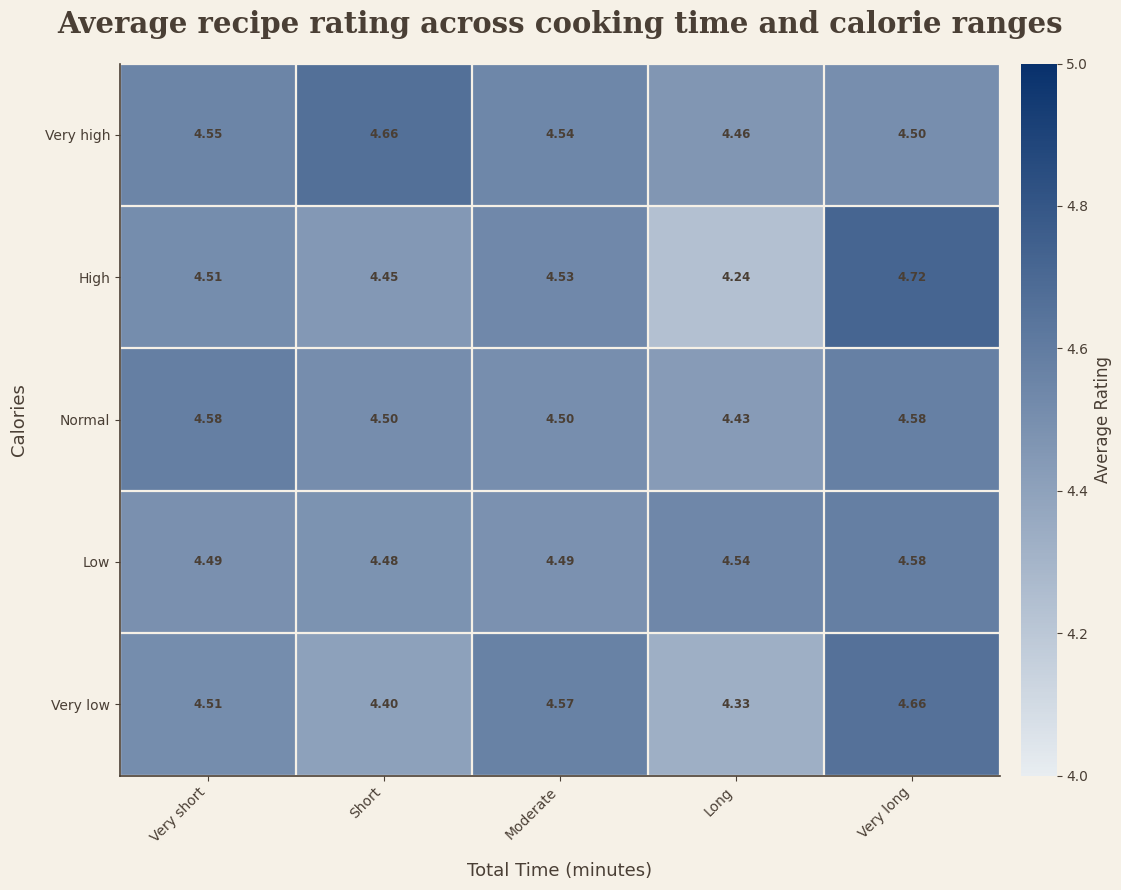

In [38]:
#plot 3: no cuisine/country here; comparison between ratings against calories/cooking time 
from matplotlib.colors import LinearSegmentedColormap

heatmap_data = cuisines_cleaned[['total_time', 'calories', 'avg_rating']].copy()

calorie_labels = ['Very low', 'Low', 'Normal', 'High', 'Very high']
time_labels = ['Very short', 'Short', 'Moderate', 'Long', 'Very long']

heatmap_data['calories_bin'] = pd.cut(
    heatmap_data['calories'], 
    bins=cuisines_by_calories_binned['calories_bin'].cat.categories, 
    labels=calorie_labels,
    include_lowest=True
)
heatmap_data['time_bin'] = pd.cut(
    heatmap_data['total_time'], 
    bins=cuisines_by_total_time_binned['total_time_bin'].cat.categories, 
    labels=time_labels,
    include_lowest=True
)

# for reference
print("Calorie Bins:")
for i, bin_range in enumerate(cuisines_by_calories_binned['calories_bin'].cat.categories):
    print(f"{calorie_labels[i]}: {bin_range}")

print("\nTime Bins:")
for i, bin_range in enumerate(cuisines_by_total_time_binned['total_time_bin'].cat.categories):
    print(f"{time_labels[i]}: {bin_range}")

rating_grid = (
    heatmap_data
    .groupby(['calories_bin', 'time_bin'])['avg_rating']
    .mean()
    .unstack()
)

rating_grid.index = calorie_labels
rating_grid.columns = time_labels

# colormap
recipe_cmap = LinearSegmentedColormap.from_list(
    'recipe_rating',
    ['#E8EDF1', '#08316C']
)

bg_color = '#F6F1E7'
panel_color = '#F3EBDD'
text_color = '#4A3F35'
grid_color = '#B8AA96'

fig, ax = plt.subplots(figsize=(12, 9), facecolor=bg_color)
ax.set_facecolor(panel_color)

im = ax.imshow(
    rating_grid,
    origin='lower',
    aspect='auto',
    cmap=recipe_cmap,
    vmin=4,
    vmax=5
)

x_labels = rating_grid.columns
y_labels = rating_grid.index

ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10, color=text_color)

ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=10, color=text_color)

ax.set_title(
    'Average recipe rating across cooking time and calorie ranges',
    fontsize=21,
    weight='bold',
    color=text_color,
    pad=22,
    family='serif'
)

ax.set_xlabel('Total Time (minutes)', fontsize=13, color=text_color, labelpad=12)
ax.set_ylabel('Calories', fontsize=13, color=text_color, labelpad=12)

for i in range(rating_grid.shape[0]):
    for j in range(rating_grid.shape[1]):
        value = rating_grid.iloc[i, j]
        if pd.notnull(value):
            ax.text(
                j, i, f"{value:.2f}",
                ha='center',
                va='center',
                fontsize=8.5,
                color='white' if value < 3.6 else text_color,
                weight='bold'
            )

ax.set_xticks(np.arange(-0.5, rating_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, rating_grid.shape[0], 1), minor=True)
ax.grid(which='minor', color=bg_color, linestyle='-', linewidth=1.6)
ax.tick_params(which='minor', bottom=False, left=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(text_color)
    ax.spines[spine].set_linewidth(1.2)

ax.tick_params(axis='x', colors=text_color)
ax.tick_params(axis='y', colors=text_color)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Average Rating', fontsize=12, color=text_color)
cbar.ax.tick_params(labelsize=10, colors=text_color)
cbar.outline.set_visible(False)


plt.tight_layout()
plt.show()


From the heatmap, we observe that average recipe ratings are generally high across both cooking time and calorie ranges, ranging between approximately 4.3 and 4.7. While the ratings remain relatively stable, more detailed patterns emerge when examining specific sections of the grid. In particular, there is a trend towards higher ratings for very long total times, with ratings remaining at 4.50 or above for all calorie tiers. This suggests that users may perceive more labor-intensive recipes as being of higher quality, leading to higher ratings.

On the other hand, we note that in the long total time category, high-calorie and low-calorie recipes attained lower ratings of 4.24 and 4.33 respectively. This suggests that the long amount of time invested was not proportionate to the result of the final dish, resulting in lower ratings. 

Additionally, very high-calorie recipes with short total times performed well with an average rating of 4.66. This may indicate that users enjoy recipes that are efficient and satisfying, offering high payout for minimal effort.

Overall, the heatmap suggests that user satisfaction is maximised when the recipes are either more high-effort or when they are time-efficient. However, it remains that user ratings are not strongly driven by total time and calories alone, meaning that other factors such as cuisine type may play a more significant role in determining ratings.


## Discussion

Overall, the three plots suggest that the recipe’s ratings are not shaped by a single factor alone. Across the bubble plot, highly rated cuisines appear across a broad spread of calorie and total-time profiles, showing that there is no one “optimal” recipe formula that guarantees stronger ratings. The heatmap reinforces this by showing that average ratings remain relatively high across most calorie and cooking-time combinations, with only modest variation between cells. Together, these findings imply that while total time and calories may influence user perceptions at the margins, they do not strongly determine ratings on their own. Instead, the consistently high ratings across much of the dataset suggest that users may generally rate recipes favourably unless there is a particularly poor match between effort and outcome.

At the same time, the choropleth and bubble plot indicate that cuisine type likely plays a more meaningful role in shaping user reception. Certain cuisines, especially several European cuisines, tend to receive slightly stronger ratings, while others cluster at somewhat lower averages, even when their calorie and cooking-time profiles are not especially extreme. This suggests that cultural familiarity, popularity, user expectations, and the way recipes are represented in the dataset may all contribute to differences in ratings. Therefore, the main takeaway from this analysis is that recipe ratings are best understood as the result of an interaction between numerical recipe characteristics and broader cuisine-level preferences. For future analysis, it would be useful to incorporate additional variables such as number of reviews, ingredients, difficulty, or user familiarity, as these may help explain more of the variation that calories and total time alone cannot capture. 

In conclusion, to answer our overarching question, our analysis suggests that recipe ratings are not determined by a single isolated variable. Instead, they appear to be influenced by a multifaceted combination of factors, including latent variables that fall outside the scope of the dataset. 


## Teamwork
Data Cleaning  - Xuan Wei, Gabriel <br>
Plots - Jieyi <br>
Introduction - Harini <br>
Discussion - Agatha <br>
Writeup - Marsya <br>



## References
### Data Source
Mubia, B. (2025). tastyR: Recipe Data from “Allrecipes.com”. https://doi.org/10.32614/cran.package.tastyr
